In [101]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nsr51324/sentiment-dataset/3) Sentiment dataset.csv


In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

import re
import warnings
warnings.filterwarnings('ignore')
 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [103]:
df = pd.read_csv("/kaggle/input/datasets/nsr51324/sentiment-dataset/3) Sentiment dataset.csv")
df

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [105]:
df['Sentiment'].value_counts()

Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64

In [106]:
df = df[['Text','Sentiment']]

In [107]:
df

,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral
...,...,...
727,Collaborating on a science project that receiv...,Happy
728,Attending a surprise birthday party organized ...,Happy
729,Successfully fundraising for a school charity ...,Happy
730,"Participating in a multicultural festival, cel...",Happy


In [108]:
df.duplicated().sum()

np.int64(24)

In [109]:
df.describe(include='O')

,Text,Sentiment
count,732,732
unique,707,279
top,"A compassionate rain, tears of empathy fallin...",Positive
freq,3,44


In [110]:
df.rename(columns={'Sentiment': 'Status'} , inplace=True)

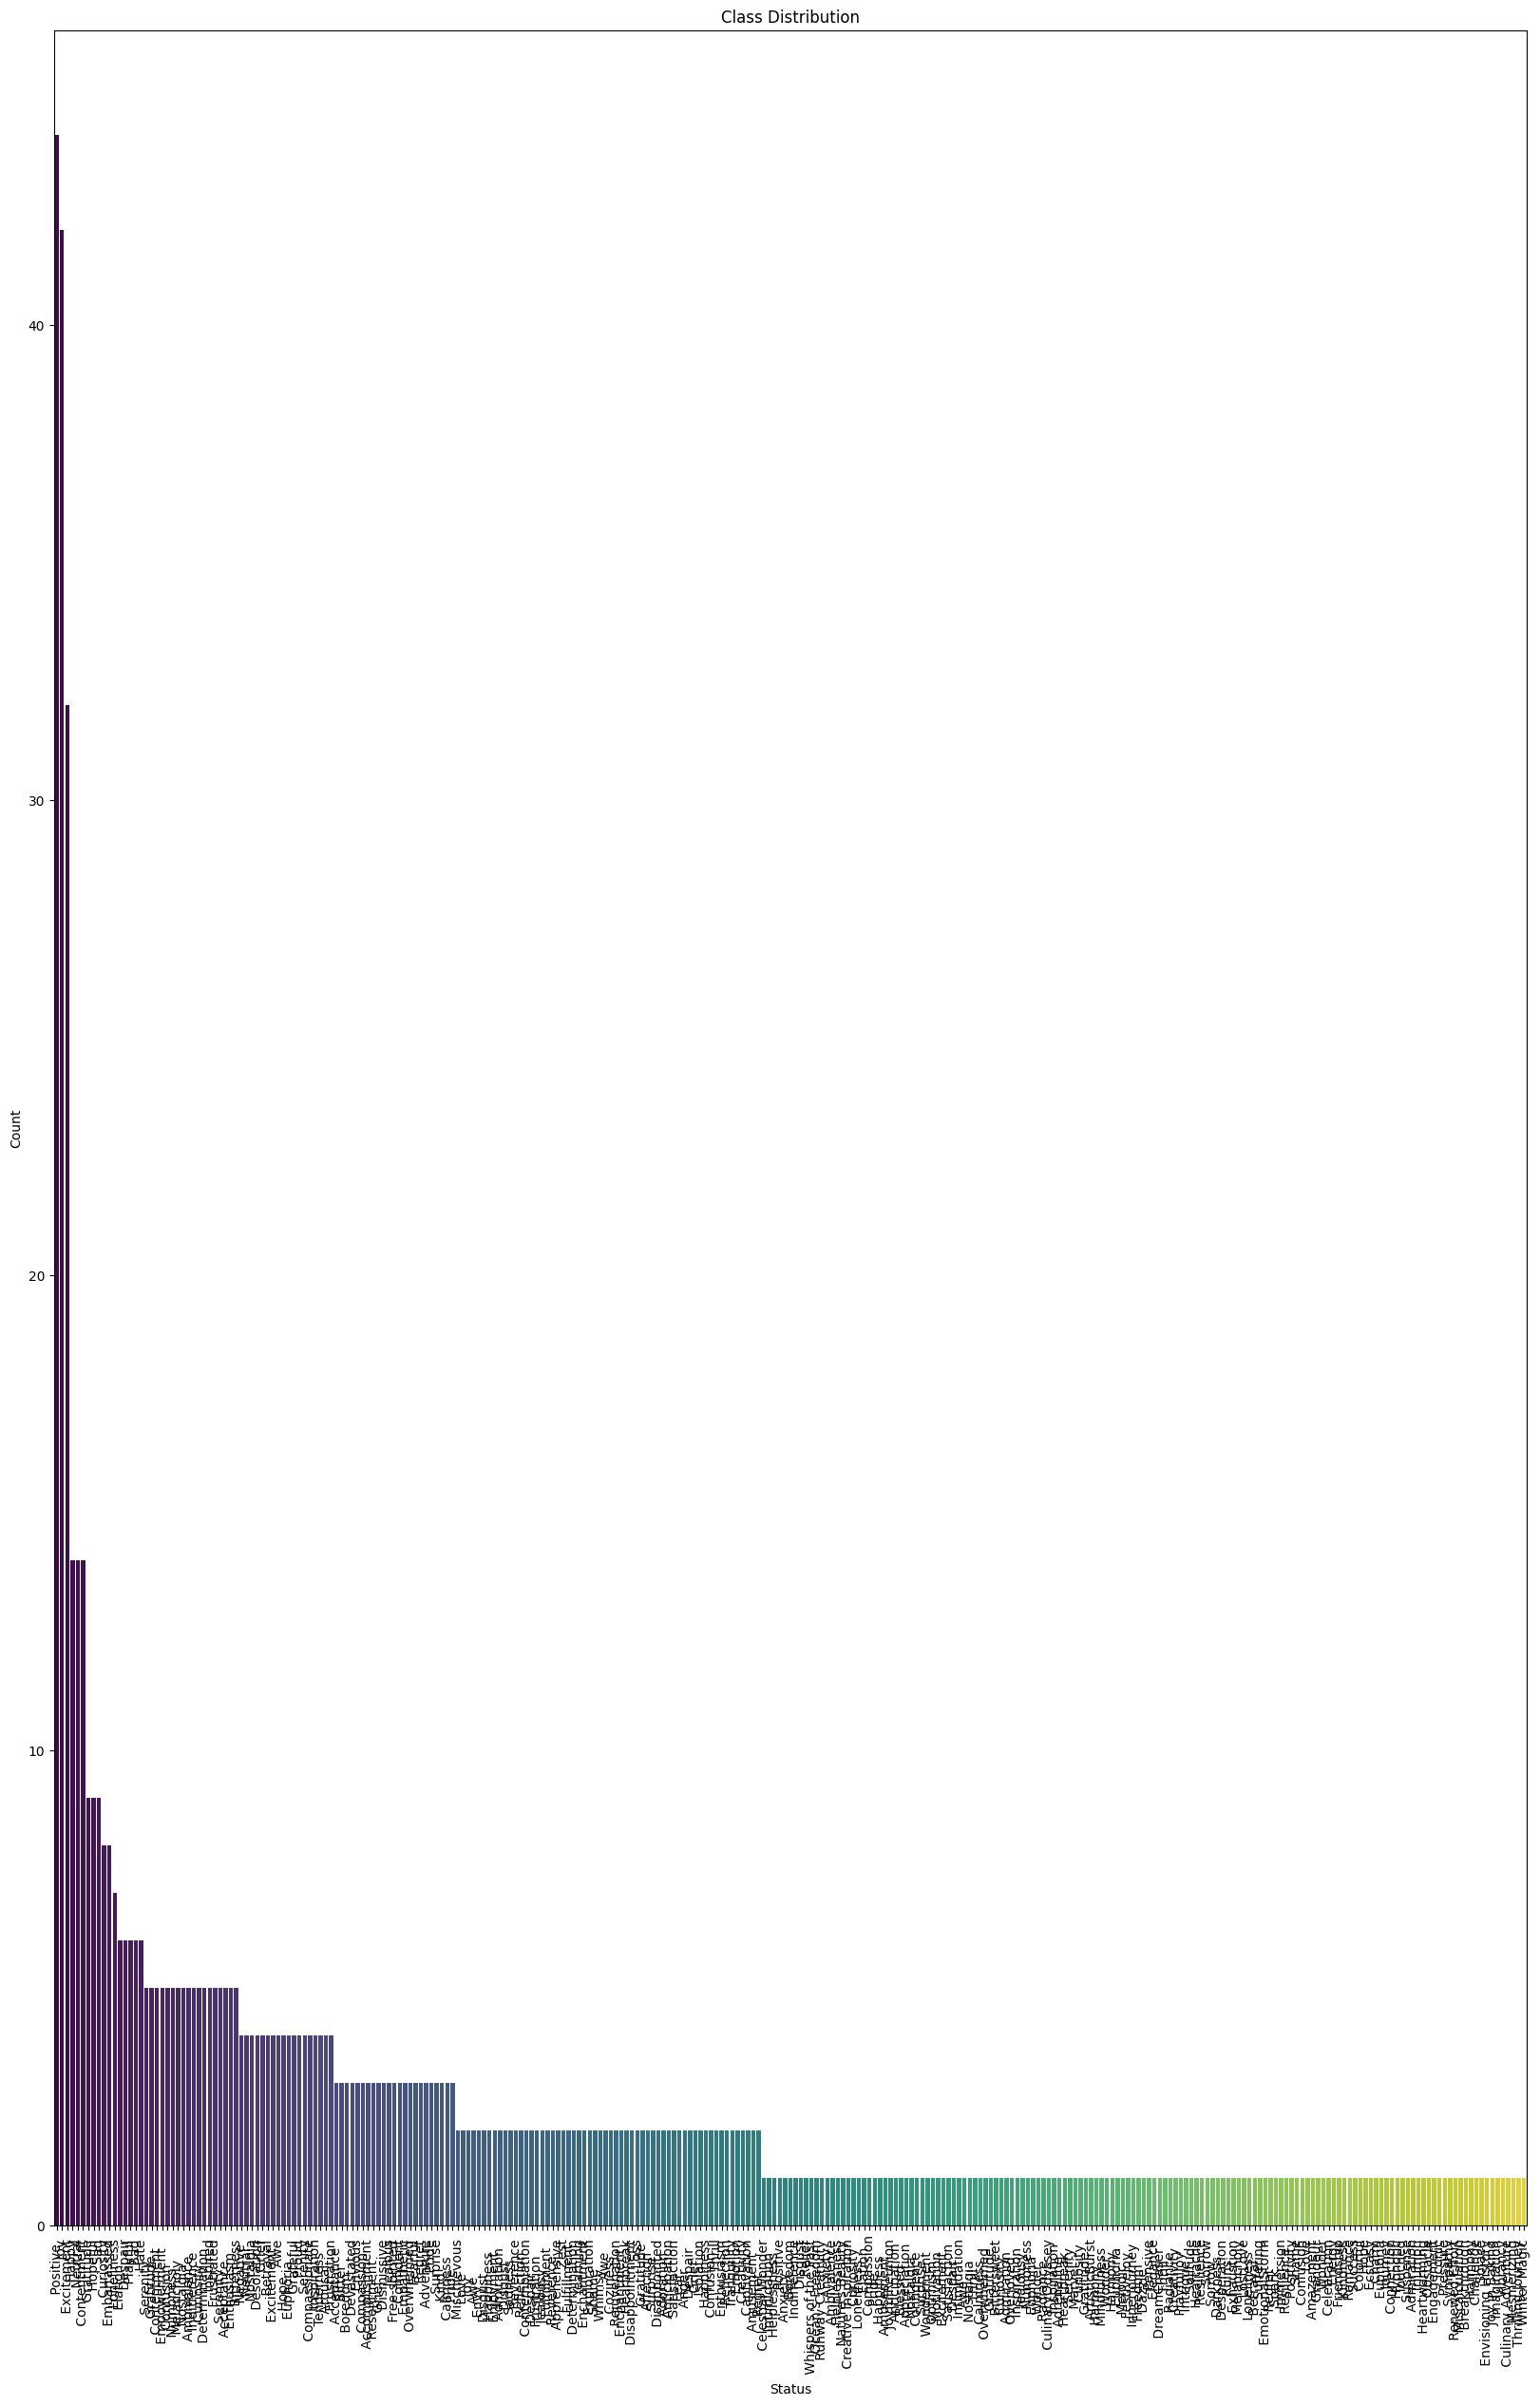

In [111]:
counts = df['Status'].value_counts()

plt.figure(figsize=(20,30))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xlabel("Status")
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [112]:
df['Status'].nunique()

279

In [113]:
POSITIVE_LABELS = {
    'Positive', 'Positivity', 'Joy', 'JoyfulReunion', 'Joy in Baking',
    'FestiveJoy', 'PlayfulJoy', 'Happiness', 'Happy', 'Excitement',
    'Elation', 'Euphoria', 'Ecstasy', 'Overjoyed', 'Contentment',
    'Satisfaction', 'Fulfillment', 'Gratitude', 'Grateful', 'Appreciation',
    'Love', 'LostLove', 'Affection', 'Tenderness', 'Adoration',
    'Romance', 'Hope', 'Hopeful', 'Optimism', 'Inspiration', 'Inspired',
    'Motivation', 'Enthusiasm', 'Empowerment', 'Confidence', 'Confident',
    'Pride', 'Proud', 'Accomplishment', 'Triumph', 'Success', 'Breakthrough',
    'Determination', 'Resilience', 'Serenity', 'Calmness', 'Tranquility',
    'Harmony', 'Peace', 'Mindfulness', 'Acceptance', 'Relief', 'Rejuvenation',
    'Compassion', 'Compassionate', 'Kindness', 'Kind', 'Empathetic', 'Sympathy',
    'Awe', 'Wonder', 'Wonderment', 'Amazement', 'Enchantment', 'Captivation',
    'Admiration', 'Reverence', 'Mesmerizing', 'Hypnotic', 'Marvel', 'Dazzle',
    'Celebration', 'Playful', 'Mischievous', 'Amusement', 'Free-spirited',
    'Adventure', 'Exploration', 'Thrill', 'Thrilling Journey', 'Adrenaline',
    'Zest', 'Energy', 'Vibrancy', 'Radiance', 'Colorful', 'Elegance',
    'Grandeur', 'Iconic', 'Creativity', 'Creative Inspiration', 'ArtisticBurst',
    'Imagination', 'Spark', 'Runway Creativity', 'Blessed', 'Heartwarming',
    'Touched', 'Connection', 'Friendship', 'Engagement', 'Enjoyment',
    'Anticipation', 'Curiosity', 'Intrigue', 'Immersion',
    'CulinaryOdyssey', 'Culinary Adventure', 'Nostalgia', 'Solace',
    'Whimsy', 'Freedom', 'Ocean\'s Freedom', 'DreamChaser', 'Journey',
    'InnerJourney', 'Nature\'s Beauty', 'Celestial Wonder',
    'Envisioning History', 'Winter Magic', 'Melodic',
    'Renewed Effort', 'Obstacle', 'Challenge',
    'Whispers of the Past', 'Ruins',
}
 
NEGATIVE_LABELS = {
    'Negative', 'Bad', 'Sadness', 'Sad', 'Grief', 'Sorrow', 'Despair',
    'Desperation', 'Desolation', 'Heartbreak', 'Heartache', 'Loss',
    'Loneliness', 'Isolation', 'Solitude', 'Melancholy', 'Bittersweet',
    'Bitter', 'Bitterness', 'Regret', 'Shame', 'Guilt',
    'Anger', 'Hate', 'Disgust', 'Frustration', 'Frustrated', 'Resentment',
    'Betrayal', 'Devastated', 'Disappointed', 'Disappointment',
    'Fear', 'Fearful', 'Anxiety', 'Apprehensive', 'Intimidation',
    'Overwhelmed', 'Helplessness', 'Numbness', 'Suffering',
    'Jealous', 'Jealousy', 'Envious', 'Envy',
    'Embarrassed', 'Dismissive', 'Darkness', 'EmotionalStorm',
    'Exhaustion', 'Pressure', 'Miscalculation',
}
 
NEUTRAL_LABELS = {
    'Neutral', 'Boredom', 'Indifference', 'Surprise', 'Ambivalence',
    'Contemplation', 'Reflection', 'Pensive', 'Confusion',
    'Emotion', 'Nostalgia', 'Yearning',
}
 

In [114]:
def map_sentiment(s):
    if s in POSITIVE_LABELS:
        return 'Positive'
    elif s in NEGATIVE_LABELS:
        return 'Negative'
    elif s in NEUTRAL_LABELS:
        return 'Neutral'
    else:
        # Fallback: use keyword matching on the label itself
        s_lower = s.lower()
        positive_kws = ['joy', 'happy', 'love', 'excit', 'hope', 'good', 'great',
                        'wonder', 'bliss', 'cheer', 'delight', 'thrill', 'warm',
                        'posit', 'calm', 'peace', 'serene', 'grate', 'proud',
                        'free', 'bright', 'spirit', 'enchant', 'beauty']
        negative_kws = ['sad', 'anger', 'fear', 'hate', 'disgust', 'depres',
                        'anxi', 'grief', 'pain', 'bad', 'negat', 'dark',
                        'lonely', 'hurt', 'bitter', 'regret', 'shame',
                        'disappoint', 'frustrat', 'exhaust']
        for kw in positive_kws:
            if kw in s_lower:
                return 'Positive'
        for kw in negative_kws:
            if kw in s_lower:
                return 'Negative'
        return 'Neutral'
 
df['Status_Group'] = df['Status'].apply(map_sentiment)

In [115]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [116]:
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove emojis and non-ASCII
    text = text.encode('ascii', 'ignore').decode()
    # 5. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 6. Tokenize
    tokens = word_tokenize(text)
    # 7. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # 8. Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens if len(t) > 1]
    return ' '.join(tokens)
 
df['Text_Clean'] = df['Text'].apply(preprocess_text)

In [117]:
df

,Text,Status,Status_Group,Text_Clean
0,Enjoying a beautiful day at the park! ...,Positive,Positive,enjoying beautiful day park
1,Traffic was terrible this morning. ...,Negative,Negative,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,Positive,Positive,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,Positive,Positive,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,Neutral,Neutral,trying new recipe dinner tonight
...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,Positive,collaborating science project received recogni...
728,Attending a surprise birthday party organized ...,Happy,Positive,attending surprise birthday party organized fr...
729,Successfully fundraising for a school charity ...,Happy,Positive,successfully fundraising school charity initia...
730,"Participating in a multicultural festival, cel...",Happy,Positive,participating multicultural festival celebrati...


In [118]:
label_encoder = LabelEncoder()

df['Status_Group'] = label_encoder.fit_transform(df['Status_Group'])
df.head()

,Text,Status,Status_Group,Text_Clean
0,Enjoying a beautiful day at the park! ...,Positive,2,enjoying beautiful day park
1,Traffic was terrible this morning. ...,Negative,0,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,Positive,2,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,Positive,2,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,Neutral,1,trying new recipe dinner tonight


In [119]:
x = df['Text_Clean']
y = df['Status_Group']

In [120]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y ,random_state=42)

In [121]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer( max_features=5000,ngram_range=(1, 2),min_df=2,sublinear_tf=True )

X_train_tfidf = vectorizer.fit_transform(x_train)
X_test_tfidf = vectorizer.transform(x_test)

In [122]:
model = MultinomialNB(alpha=0.5)

model.fit(X_train_tfidf, y_train)

MultinomialNB(alpha=0.5)

In [123]:
y_pred = model.predict(X_test_tfidf)

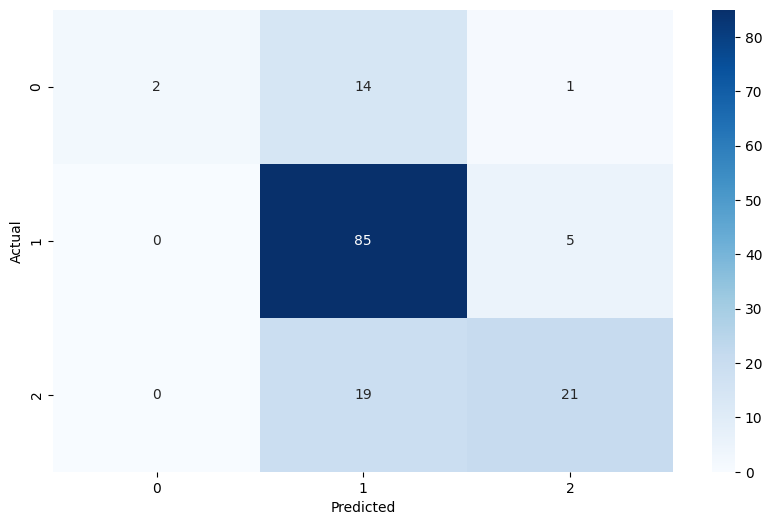

In [124]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [125]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.12      0.21        17
           1       0.72      0.94      0.82        90
           2       0.78      0.53      0.63        40

    accuracy                           0.73       147
   macro avg       0.83      0.53      0.55       147
weighted avg       0.77      0.73      0.70       147



In [126]:
# Model Training with Hyperparameter Tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

model = LogisticRegression(class_weight='balanced',max_iter=1000)
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_tfidf, y_train)

best_model = grid_search.best_estimator_

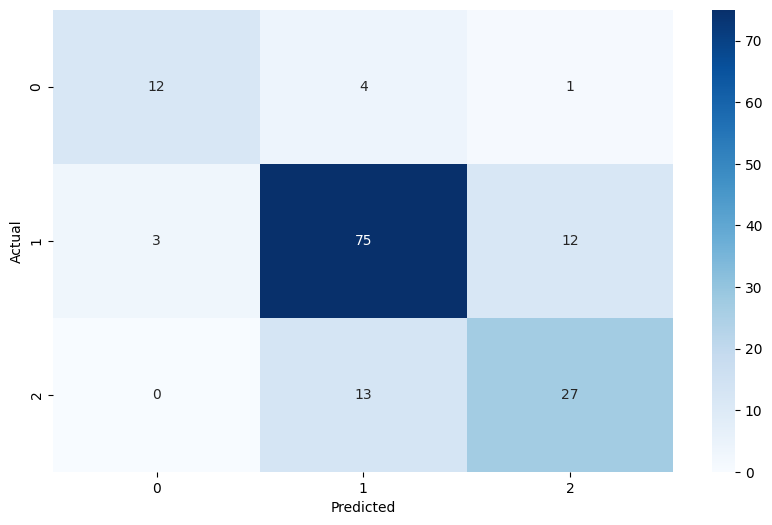

In [127]:
y_pred = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [128]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Best Parameters:
{'C': 10}
Accuracy Score:
0.7755102040816326
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.71      0.75        17
           1       0.82      0.83      0.82        90
           2       0.68      0.68      0.68        40

    accuracy                           0.78       147
   macro avg       0.76      0.74      0.75       147
weighted avg       0.78      0.78      0.78       147

